Random pumping schedule (1=on, 0=off):
[0 1 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0
 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1]
Transmissivity (T): 7.385 m^2/day
Storativity (S): 0.014770
Observation distance (r): 500.0 meters
Noise std dev: 0.100 m
Max true drawdown: 1.224 m


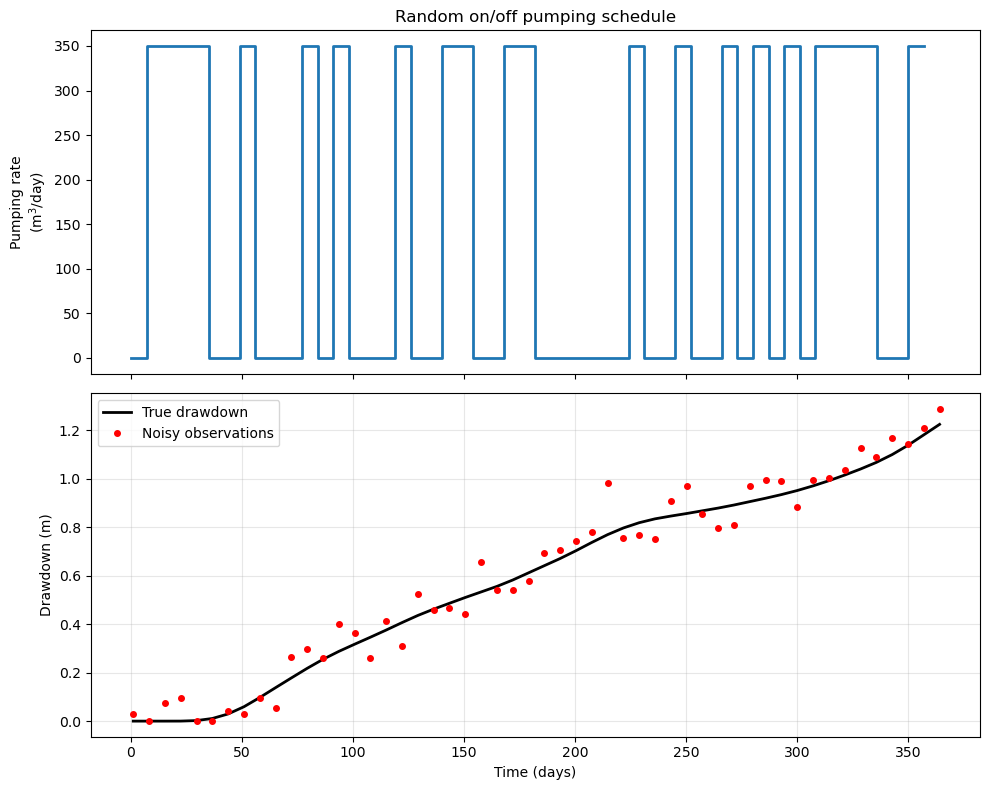

c:\Users\kaden.mcculloch\AppData\Local\anaconda3\envs\kfm-ms\Lib\site-packages\pyemu\pst\pst_utils.py:922: UserWarning: error processing instruction file drawdown.csv.ins, trying inschek: InstructionFile error processing output file on line number 1: casting string 'obsnme' to float for instruction '!s_00!'



Parameter table before edits:
      parnme partrans parchglim  parval1       parlbnd       parubnd  pargp  \
sch01  sch01      log    factor      1.0  1.100000e-10  1.100000e+10  pargp   
sch02  sch02      log    factor      1.0  1.100000e-10  1.100000e+10  pargp   
sch03  sch03      log    factor      1.0  1.100000e-10  1.100000e+10  pargp   
sch04  sch04      log    factor      1.0  1.100000e-10  1.100000e+10  pargp   
sch05  sch05      log    factor      1.0  1.100000e-10  1.100000e+10  pargp   

       scale  offset  dercom  
sch01    1.0     0.0       1  
sch02    1.0     0.0       1  
sch03    1.0     0.0       1  
sch04    1.0     0.0       1  
sch05    1.0     0.0       1  
noptmax:0, npar_adj:52, nnz_obs:52

Done. Wrote demo/theis_pest_v2.pst

PESTPP-IES stdout:


             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team

...processing command line: ' c:\Python\Personal\kfm-ms\codes\binaries\PESTPP\windows\pestpp-ies.exe the

In [ ]:
### NOT USED ###

# import os
# import shutil
# import subprocess
# import numpy as np
# import scipy.special as sp
# import pandas as pd
# import pyemu
# import matplotlib.pyplot as plt

# # =================================================
# # User settings
# # =================================================
# pestpp_ies_exe = r"c:\Python\Personal\kfm-ms\codes\binaries\PESTPP\windows\pestpp-ies.exe"

# # Noise settings
# noise_std = 0.10   # meters
# noise_seed = 42

# # Random pumping schedule settings
# schedule_seed = 123
# on_probability = 0.35   # probability a week is pumping on

# # =================================================
# # Paths
# # =================================================
# notebook_dir = os.getcwd()
# base_template_dir = os.path.join(notebook_dir, "model_base")
# demo_dir = os.path.join(notebook_dir, "demo")

# shutil.rmtree(base_template_dir, ignore_errors=True)
# shutil.rmtree(demo_dir, ignore_errors=True)
# os.makedirs(base_template_dir, exist_ok=True)
# os.makedirs(demo_dir, exist_ok=True)

# # =================================================
# # Temporal / spatial settings
# # =================================================
# cell_dim = 100.0  # m
# nper = 52
# perlen = 7.0      # days
# total_days = nper * perlen
# time_array = np.linspace(1.0, total_days, nper)

# # stress period boundaries
# t_edges = np.arange(0.0, total_days + perlen, perlen)  # 0, 7, 14, ..., 364

# # =================================================
# # Aquifer properties
# # =================================================
# hydraulic_conductivity = 0.005  # m/day
# aquifer_thickness = 1477.0      # m
# transmissivity = hydraulic_conductivity * aquifer_thickness
# Ss = 1e-5
# storativity = Ss * aquifer_thickness

# # =================================================
# # Geometry
# # =================================================
# well_buffer_cells = 5
# r_distance = well_buffer_cells * cell_dim  # 500 m

# # =================================================
# # True pumping parameters
# # =================================================
# Q_true = 350.0  # when well is ON

# def theis_step_response(Q, t0, t_array, T, S, r):
#     """
#     Theis drawdown from a constant-rate step starting at time t0.
#     """
#     out = []
#     for t in t_array:
#         if t <= t0:
#             out.append(0.0)
#         else:
#             dt = t - t0
#             u = (r**2 * S) / (4.0 * T * dt)
#             out.append((Q / (4.0 * np.pi * T)) * sp.exp1(u))
#     return np.array(out)

# def theis_piecewise_constant(schedule, Q_on, t_edges, t_array, T, S, r):
#     """
#     Drawdown from a piecewise-constant on/off pumping schedule.
#     schedule: array of 0/1 of length nper
#     Each stress period contributes a step increase at its start and step decrease at its end.
#     """
#     drawdown = np.zeros_like(t_array, dtype=float)

#     for k in range(len(schedule)):
#         if schedule[k] == 1:
#             t_start = t_edges[k]
#             t_end = t_edges[k + 1]
#             # step-on contribution
#             drawdown += theis_step_response(Q_on, t_start, t_array, T, S, r)
#             # step-off contribution at the end of the interval
#             drawdown -= theis_step_response(Q_on, t_end, t_array, T, S, r)

#     return drawdown

# # =================================================
# # Create random on/off schedule
# # =================================================
# rng_sched = np.random.default_rng(schedule_seed)
# pumping_schedule = (rng_sched.random(nper) < on_probability).astype(int)

# # make sure there is at least some pumping
# if pumping_schedule.sum() == 0:
#     pumping_schedule[rng_sched.integers(0, nper)] = 1

# print("Random pumping schedule (1=on, 0=off):")
# print(pumping_schedule)

# # =================================================
# # Generate true drawdown and noisy observations
# # =================================================
# s_true_series = theis_piecewise_constant(
#     pumping_schedule, Q_true, t_edges, time_array, transmissivity, storativity, r_distance
# )

# rng_noise = np.random.default_rng(noise_seed)
# s_obs_series = s_true_series + rng_noise.normal(0.0, noise_std, size=s_true_series.shape)
# s_obs_series = np.clip(s_obs_series, 0.0, None)

# print(f"Transmissivity (T): {transmissivity:.3f} m^2/day")
# print(f"Storativity (S): {storativity:.6f}")
# print(f"Observation distance (r): {r_distance} meters")
# print(f"Noise std dev: {noise_std:.3f} m")
# print(f"Max true drawdown: {s_true_series.max():.3f} m")

# # =================================================
# # Plot true schedule and noisy data
# # =================================================
# fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ax[0].step(t_edges[:-1], pumping_schedule * Q_true, where="post", lw=2, color="tab:blue")
# ax[0].set_ylabel("Pumping rate\n(m$^3$/day)")
# ax[0].set_title("Random on/off pumping schedule")

# ax[1].plot(time_array, s_true_series, "k-", lw=2, label="True drawdown")
# ax[1].plot(time_array, s_obs_series, "ro", ms=4, label="Noisy observations")
# ax[1].set_xlabel("Time (days)")
# ax[1].set_ylabel("Drawdown (m)")
# ax[1].legend()
# ax[1].grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

# # =================================================
# # Base model files
# # =================================================
# # We'll keep the forward model simple: it reads a weekly on/off schedule
# # from schedule.csv and computes drawdown.
# schedule_df = pd.DataFrame({
#     "week": np.arange(1, nper + 1),
#     "pump_on": pumping_schedule
# })
# schedule_df.to_csv(os.path.join(base_template_dir, "schedule.csv"), index=False)

# # placeholder observation file
# df_obs_base = pd.DataFrame({
#     "obsnme": [f"s_{i:02d}" for i in range(nper)],
#     "simval": [0.0] * nper
# })
# df_obs_base.to_csv(os.path.join(base_template_dir, "drawdown.csv"), index=False)

# # =================================================
# # Forward model script
# # Reads schedule.csv and writes plain-text drawdown.csv
# # =================================================
# forward_script_path = os.path.join(base_template_dir, "theis_forward.py")
# with open(forward_script_path, "w", newline="\n") as f:
#     f.write(
#         """import numpy as np
# import scipy.special as sp
# import pandas as pd

# def theis_step_response(Q, t0, t_array, T, S, r):
#     out = []
#     for t in t_array:
#         if t <= t0:
#             out.append(0.0)
#         else:
#             dt = t - t0
#             u = (r**2 * S) / (4.0 * T * dt)
#             out.append((Q / (4.0 * np.pi * T)) * sp.exp1(u))
#     return np.array(out)

# def run_theis():
#     # read weekly schedule
#     df_sched = pd.read_csv("schedule.csv")
#     schedule = df_sched["pump_on"].values.astype(int)

#     Q_on = 350.0
#     T = 0.005 * 1477.0
#     S = 1e-5 * 1477.0
#     r = 500.0

#     nper = len(schedule)
#     perlen = 7.0
#     t_edges = np.arange(0.0, nper * perlen + perlen, perlen)
#     time_array = np.linspace(1.0, nper * perlen, nper)

#     def theis_step_response(Q, t0, t_array, T, S, r):
#         out = []
#         for t in t_array:
#             if t <= t0:
#                 out.append(0.0)
#             else:
#                 dt = t - t0
#                 u = (r**2 * S) / (4.0 * T * dt)
#                 out.append((Q / (4.0 * np.pi * T)) * sp.exp1(u))
#         return np.array(out)

#     drawdown = np.zeros_like(time_array, dtype=float)
#     for k in range(nper):
#         if schedule[k] == 1:
#             t_start = t_edges[k]
#             t_end = t_edges[k + 1]
#             drawdown += theis_step_response(Q_on, t_start, time_array, T, S, r)
#             drawdown -= theis_step_response(Q_on, t_end, time_array, T, S, r)

#     with open("drawdown.csv", "w") as f:
#         for val in drawdown:
#             f.write(f"{val}\\n")

# if __name__ == "__main__":
#     run_theis()
# """
#     )

# # =================================================
# # Template and instruction files
# # =================================================
# # For schedule.csv, use a binary parameter for each week
# with open(os.path.join(base_template_dir, "schedule.csv.tpl"), "w", newline="\n") as f:
#     f.write("ptf ~\n")
#     f.write("week,pump_on\n")
#     for i in range(nper):
#         f.write(f"{i+1},~ sch{i+1:02d} ~\n")

# with open(os.path.join(base_template_dir, "drawdown.csv.ins"), "w", newline="\n") as f:
#     f.write("pif ~\n")
#     for i in range(nper):
#         f.write(f"l1 !s_{i:02d}!\n")

# # Copy everything into demo folder
# shutil.copytree(base_template_dir, demo_dir, dirs_exist_ok=True)

# # =================================================
# # Build Pst from IO files
# # =================================================
# cwd = os.getcwd()
# os.chdir(demo_dir)
# try:
#     pst = pyemu.Pst.from_io_files(
#         tpl_files=["schedule.csv.tpl"],
#         in_files=["schedule.csv"],
#         ins_files=["drawdown.csv.ins"],
#         out_files=["drawdown.csv"],
#         pst_path="."
#     )
# finally:
#     os.chdir(cwd)

# # =================================================
# # Parameter settings
# # =================================================
# for col in ["parval1", "parlbnd", "parubnd"]:
#     if col in pst.parameter_data.columns:
#         pst.parameter_data[col] = pd.to_numeric(pst.parameter_data[col], errors="coerce")

# print("\nParameter table before edits:")
# print(pst.parameter_data.head())

# # make all schedule parameters binary-ish multipliers
# for pname in pst.parameter_data.index:
#     pst.parameter_data.loc[pname, "parval1"] = 1.0
#     pst.parameter_data.loc[pname, "parlbnd"] = 0.0
#     pst.parameter_data.loc[pname, "parubnd"] = 1.0
#     pst.parameter_data.loc[pname, "partrans"] = "none"
#     pst.parameter_data.loc[pname, "pargp"] = "schedule"

# # =================================================
# # Observation settings
# # =================================================
# for i, s_val in enumerate(s_obs_series):
#     obs_name = f"s_{i:02d}"
#     if obs_name in pst.observation_data.index:
#         pst.observation_data.loc[obs_name, "obsval"] = float(s_val)
#         pst.observation_data.loc[obs_name, "weight"] = 1.0
#         pst.observation_data.loc[obs_name, "obgnme"] = "drawdown"

# # =================================================
# # Control settings
# # =================================================
# pst.control_data.noptmax = 0
# pst.model_command = "python theis_forward.py"

# # =================================================
# # Write version-2 PCF
# # =================================================
# cwd = os.getcwd()
# os.chdir(demo_dir)
# try:
#     pst.write("theis_pest_v2.pst", version=2)
# finally:
#     os.chdir(cwd)

# print("\nDone. Wrote demo/theis_pest_v2.pst")

# # =================================================
# # Run PESTPP-IES
# # =================================================
# result = subprocess.run(
#     [pestpp_ies_exe, "theis_pest_v2.pst"],
#     cwd=demo_dir,
#     capture_output=True,
#     text=True
# )

# print("\nPESTPP-IES stdout:")
# print(result.stdout)

# print("\nPESTPP-IES stderr:")
# print(result.stderr)

# print(f"\nReturn code: {result.returncode}")

# if result.returncode != 0:
#     raise RuntimeError("PESTPP-IES run failed. See stdout/stderr above.")

Truth:
  Q = 350

Best-Fit Alternatives:
Lower and Earlier: Q = 317
Higher and Later: Q = 407


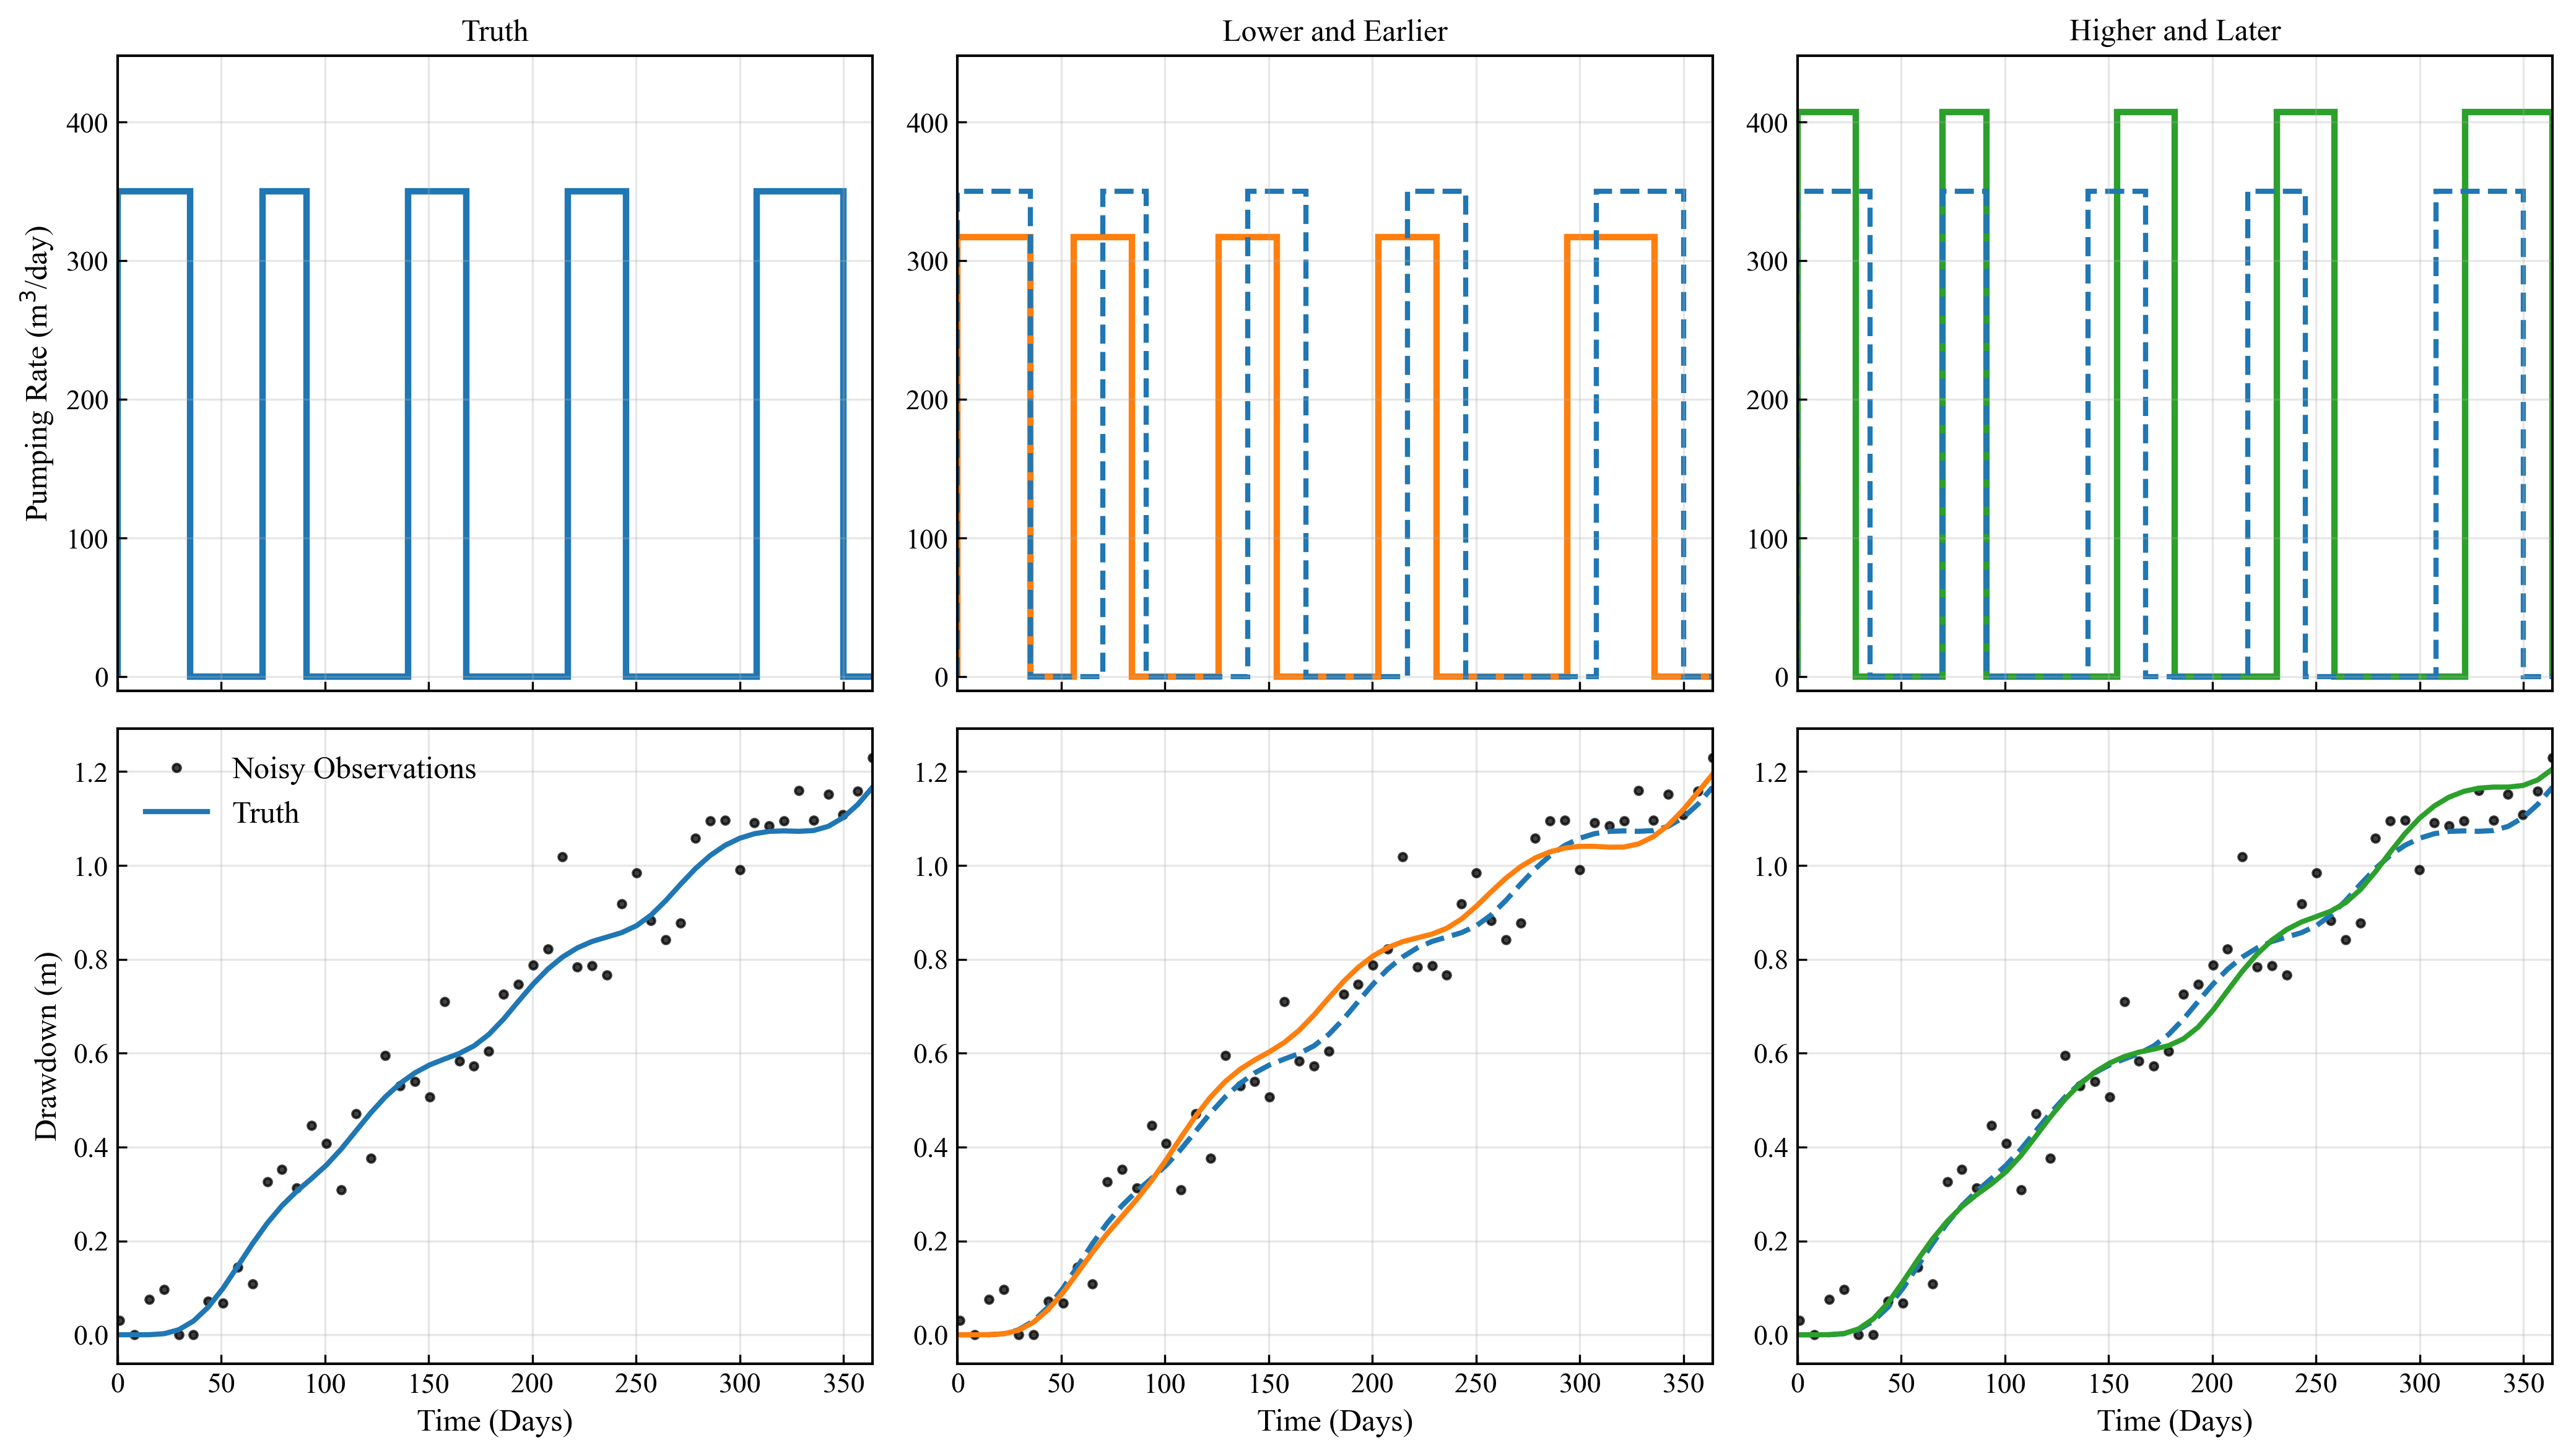

In [25]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

# =================================================
# Global Plotting Style
# =================================================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
})

# =================================================
# Fixed Aquifer / Geometry Settings
# =================================================
cell_dim = 100.0  # m
r_distance = 500.0

hydraulic_conductivity = 0.005  # m/day
aquifer_thickness = 1477.0      # m
transmissivity = hydraulic_conductivity * aquifer_thickness
Ss = 1e-5
storativity = Ss * aquifer_thickness

# =================================================
# Time Settings
# =================================================
nper = 52
perlen = 7.0
total_days = nper * perlen
time_array = np.linspace(1.0, total_days, nper)
t_edges = np.arange(0.0, total_days + perlen, perlen)

# =================================================
# Theis Step Response
# =================================================
def theis_step_response(Q, t0, t_array, T, S, r):
    out = []
    for t in t_array:
        if t <= t0:
            out.append(0.0)
        else:
            dt = t - t0
            u = (r**2 * S) / (4.0 * T * dt)
            out.append((Q / (4.0 * np.pi * T)) * sp.exp1(u))
    return np.array(out)

def theis_piecewise_constant(schedule, Q_on, t_edges, t_array, T, S, r):
    drawdown = np.zeros_like(t_array, dtype=float)
    for k in range(len(schedule)):
        if schedule[k] == 1:
            t_start = t_edges[k]
            t_end = t_edges[k + 1]
            drawdown += theis_step_response(Q_on, t_start, t_array, T, S, r)
            drawdown -= theis_step_response(Q_on, t_end, t_array, T, S, r)
    return drawdown

# =================================================
# Helper To Make Schedules
# =================================================
def make_schedule(on_ranges, nper=52):
    s = np.zeros(nper, dtype=int)
    for a, b in on_ranges:
        s[a:b+1] = 1
    return s

def shift_schedule(schedule, shift_weeks):
    shifted = np.zeros_like(schedule)
    for i, val in enumerate(schedule):
        j = i + shift_weeks
        if 0 <= j < len(schedule):
            shifted[j] = val
    return shifted

# =================================================
# Truth
# =================================================
Q_true = 350.0
true_schedule = make_schedule([
    (0, 4),
    (10, 12),
    (20, 23),
    (31, 34),
    (44, 49)
], nper=nper)

true_drawdown = theis_piecewise_constant(
    true_schedule, Q_true, t_edges, time_array, transmissivity, storativity, r_distance
)

# Add Observational Noise
noise_std = 0.10
rng = np.random.default_rng(42)
obs_drawdown = true_drawdown + rng.normal(0.0, noise_std, size=true_drawdown.shape)
obs_drawdown = np.clip(obs_drawdown, 0.0, None)

# =================================================
# Candidate Schedules
# =================================================
candidate_schedules = {
    "Lower And Earlier": make_schedule([
        (0, 5),
        (9, 12),
        (19, 22),
        (30, 33),
        (43, 48)
    ], nper=nper),

    "Higher And Later": make_schedule([
        (0, 3),
        (10, 12),
        (22, 25),
        (33, 36),
        (46, 51)
    ], nper=nper),
}

# =================================================
# 2D Search Over Q And Timing Shift
# =================================================
Q_grid = np.linspace(250.0, 450.0, 800)
shift_grid = np.arange(-4, 5, 1)

best_cases = {}

for name, sched in candidate_schedules.items():
    name = name.replace("And", "and")
    best_misfit = np.inf
    best_Q = None
    best_shift = None
    best_sched = None
    best_sim = None

    for shift in shift_grid:
        shifted_sched = shift_schedule(sched, shift)

        for Q in Q_grid:
            sim = theis_piecewise_constant(
                shifted_sched, Q, t_edges, time_array, transmissivity, storativity, r_distance
            )
            misfit = np.sum((sim - obs_drawdown) ** 2)

            if misfit < best_misfit:
                best_misfit = misfit
                best_Q = Q
                best_shift = shift
                best_sched = shifted_sched.copy()
                best_sim = sim.copy()

    best_cases[name] = {
        "schedule": best_sched,
        "Q": best_Q,
        "shift": best_shift,
        "sim": best_sim,
        "misfit": best_misfit
    }

# =================================================
# Print Results
# =================================================
print("Truth:")
print(f"  Q = {Q_true:.0f}\n")

print("Best-Fit Alternatives:")
for name, info in best_cases.items():
    print(f"{name}: Q = {info['Q']:.0f}")

# =================================================
# Plotting: 2x3 Layout
# Top Row = Schedules
# Bottom Row = Drawdowns
# =================================================
fig, ax = plt.subplots(2, 3, figsize=(14, 8), sharex="col")

# Same Y-Axis For All Pumping Panels
all_Q_values = [Q_true] + [best_cases[name]["Q"] for name in ["Lower and Earlier", "Higher and Later"]]
global_max_Q = max(all_Q_values)

# Color-Blind Friendly Colors
truth_color = "tab:blue"
lower_color = "tab:orange"
higher_color = "tab:green"

# -------------------------------------------------
# Top Row: Schedules
# -------------------------------------------------
ax[0, 0].stairs(true_schedule * Q_true, t_edges, lw=2.5, color=truth_color)
ax[0, 0].set_title("Truth")
ax[0, 0].set_ylim(-10, 1.1 * global_max_Q)
ax[0, 0].set_xlim(0, total_days)
ax[0, 0].grid(alpha=0.3)
ax[0, 0].set_ylabel("Pumping Rate (m$^3$/day)")

for j, name in enumerate(["Lower and Earlier", "Higher and Later"], start=1):
    info = best_cases[name]

    ax[0, j].stairs(
        info["schedule"] * info["Q"],
        t_edges,
        lw=2.5,
        color=[lower_color, higher_color][j - 1]
    )

    ax[0, j].stairs(
        true_schedule * Q_true,
        t_edges,
        lw=2.0,
        color=truth_color,
        linestyle="--"
    )

    ax[0, j].set_title(name)
    ax[0, j].set_ylim(-10, 1.1 * global_max_Q)
    ax[0, j].set_xlim(0, total_days)
    ax[0, j].grid(alpha=0.3)

# -------------------------------------------------
# Bottom Row: Drawdowns
# -------------------------------------------------
ax[1, 0].plot(time_array, obs_drawdown, "ko", ms=3, alpha=0.75, label="Noisy Observations")
ax[1, 0].plot(time_array, true_drawdown, color=truth_color, lw=2.0, label="Truth")
ax[1, 0].set_xlim(0, total_days)
ax[1, 0].grid(alpha=0.3)
ax[1, 0].set_xlabel("Time (Days)")
ax[1, 0].set_ylabel("Drawdown (m)")
ax[1, 0].legend(loc="best", frameon=False)

for j, name in enumerate(["Lower and Earlier", "Higher and Later"], start=1):
    info = best_cases[name]
    panel_color = lower_color if name == "Lower and Earlier" else higher_color

    ax[1, j].plot(time_array, obs_drawdown, "ko", ms=3, alpha=0.75)
    ax[1, j].plot(time_array, true_drawdown, color=truth_color, lw=2.0, linestyle="--")
    ax[1, j].plot(time_array, info["sim"], lw=2.0, color=panel_color)
    ax[1, j].set_xlim(0, total_days)
    ax[1, j].grid(alpha=0.3)
    ax[1, j].set_xlabel("Time (Days)")

plt.tight_layout()
plt.show()